# Dataset Preparation 

## Objective

- Load the datasets
- Inspect their structure and data types
- Check for missing values
- Identify and handle inconsistencies
- Standardize numerical features
- Summarize the datasets 

## Importing required libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

In [3]:
wine = pd.read_csv("C:/Users/hp/Downloads/wine.csv")
    
chickwts = pd.read_csv("C:/Users/hp/Downloads/chickwts.csv")

usarrests = pd.read_csv("C:/Users/hp/Downloads/USArrests.csv")

##  Initial Data Inspection

Before cleaning the datasets, we inspect their dimensions, column names, data types, and first few observations.

In [4]:
print("Wine Dataset")
print(wine.shape)
print(wine.head())
print(wine.info())

Wine Dataset
(178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prolin

In [5]:
print("Chickwts Dataset")
print(wine.shape)
print(wine.head())
print(wine.info())

Chickwts Dataset
(178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  pr

In [6]:
print("USArrests Dataset")
print(wine.shape)
print(wine.head())
print(wine.info())

USArrests Dataset
(178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  p

##  Checking for Missing Values

Missing values can cause errors or reduce the performance of machine learning models. Therefore, each dataset is checked for missing values.

In [7]:
print("Wine missing values:")
print(wine.isnull().sum())

print("\nChickwts missing values:")
print(chickwts.isnull().sum())

print("\nUSArrests missing values:")
print(usarrests.isnull().sum())

Wine missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Chickwts missing values:
weight    0
feed      0
dtype: int64

USArrests missing values:
rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


##  Checking for Duplicates


In [9]:
print("Wine duplicates:", wine.duplicated().sum())
print("Chickwts duplicates:", chickwts.duplicated().sum())
print("USArrests duplicates:", usarrests.duplicated().sum())


Wine duplicates: 0
Chickwts duplicates: 1
USArrests duplicates: 0


##  Checking Data Types


In [10]:
print("Wine data types:")
print(wine.dtypes)

print("\nChickwts data types:")
print(chickwts.dtypes)

print("\nUSArrests data types:")
print(usarrests.dtypes)

Wine data types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Chickwts data types:
weight     int64
feed      object
dtype: object

USArrests data types:
rownames     object
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object


##  Standardizing Numerical Features

Standardization transforms numerical features so that they have a mean of approximately 0 and a standard deviation of 1.


In [11]:
scaler = StandardScaler()

# Wine
wine_numeric = wine.select_dtypes(include=np.number).columns
wine[wine_numeric] = scaler.fit_transform(wine[wine_numeric])


In [12]:
# Chickwts
chick_numeric = chickwts.select_dtypes(include=np.number).columns
chickwts[chick_numeric] = scaler.fit_transform(chickwts[chick_numeric])


In [13]:
# USArrests
arrests_numeric = usarrests.select_dtypes(include=np.number).columns
usarrests[arrests_numeric] = scaler.fit_transform(usarrests[arrests_numeric])

In [14]:
print("Wine:")
print(wine[wine_numeric].describe().loc[["mean", "std"]])

print("\nChickwts:")
print(chickwts[chick_numeric].describe().loc[["mean", "std"]])

print("\nUSArrests:")
print(usarrests[arrests_numeric].describe().loc[["mean", "std"]])

Wine:
           alcohol    malic_acid           ash  alcalinity_of_ash  \
mean -8.382808e-16 -1.197544e-16 -8.370333e-16      -3.991813e-17   
std   1.002821e+00  1.002821e+00  1.002821e+00       1.002821e+00   

         magnesium  total_phenols    flavanoids  nonflavanoid_phenols  \
mean -3.991813e-17       0.000000 -3.991813e-16          3.592632e-16   
std   1.002821e+00       1.002821  1.002821e+00          1.002821e+00   

      proanthocyanins  color_intensity           hue  \
mean    -1.197544e-16     2.494883e-17  1.995907e-16   
std      1.002821e+00     1.002821e+00  1.002821e+00   

      od280/od315_of_diluted_wines       proline        target  
mean                  3.193450e-16 -1.596725e-16  1.596725e-16  
std                   1.002821e+00  1.002821e+00  1.002821e+00  

Chickwts:
            weight
mean -2.720828e-16
std   1.007118e+00

USArrests:
            Murder       Assault      UrbanPop          Rape
mean -7.105427e-17  1.387779e-16 -4.396483e-16  8.593126e-16


##  Dataset Summary


In [15]:
print("===== WINE DATASET =====")
print("Shape:", wine.shape)
print("Columns:", wine.columns.tolist())
print(wine.describe())

===== WINE DATASET =====
Shape: (178, 14)
Columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']
            alcohol    malic_acid           ash  alcalinity_of_ash  \
count  1.780000e+02  1.780000e+02  1.780000e+02       1.780000e+02   
mean  -8.382808e-16 -1.197544e-16 -8.370333e-16      -3.991813e-17   
std    1.002821e+00  1.002821e+00  1.002821e+00       1.002821e+00   
min   -2.434235e+00 -1.432983e+00 -3.679162e+00      -2.671018e+00   
25%   -7.882448e-01 -6.587486e-01 -5.721225e-01      -6.891372e-01   
50%    6.099988e-02 -4.231120e-01 -2.382132e-02       1.518295e-03   
75%    8.361286e-01  6.697929e-01  6.981085e-01       6.020883e-01   
max    2.259772e+00  3.109192e+00  3.156325e+00       3.154511e+00   

          magnesium  total_phenols    flavanoids  nonflavanoid_phenols  \
count  1.780000e+02     

In [17]:
print("===== CHICKWTS DATASET =====")
print("Shape:", wine.shape)
print("Columns:", wine.columns.tolist())
print(chickwts.describe())

===== CHICKWTS DATASET =====
Shape: (178, 14)
Columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']
             weight
count  7.100000e+01
mean  -2.720828e-16
std    1.007118e+00
min   -1.977632e+00
25%   -7.328230e-01
50%   -4.269578e-02
75%    8.022264e-01
max    2.085734e+00


In [18]:
print("===== USARRESTS DATASET =====")
print("Shape:", wine.shape)
print("Columns:", wine.columns.tolist())
print(usarrests.describe())

===== USARRESTS DATASET =====
Shape: (178, 14)
Columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']
             Murder       Assault      UrbanPop          Rape
count  5.000000e+01  5.000000e+01  5.000000e+01  5.000000e+01
mean  -7.105427e-17  1.387779e-16 -4.396483e-16  8.593126e-16
std    1.010153e+00  1.010153e+00  1.010153e+00  1.010153e+00
min   -1.620693e+00 -1.524362e+00 -2.340661e+00 -1.502548e+00
25%   -8.611383e-01 -7.486054e-01 -7.704502e-01 -6.640245e-01
50%   -1.247758e-01 -1.425453e-01  3.210209e-02 -1.220847e-01
75%    8.029251e-01  9.483628e-01  8.521012e-01  5.330962e-01
max    2.229265e+00  2.015028e+00  1.776781e+00  2.671197e+00


# Recommendation System Using PCA and Cosine Similarity

The recommendation system will:

- Analyze the average chicken weight for each feed type.
- Standardize the weight feature.
- Apply Principal Component Analysis (PCA) to reduce the data to one principal component.
- Calculate cosine similarity between feed types.
- Recommend feeds that have similar characteristics based on their chicken weights.

## importing libraries

In [19]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
chickwts = pd.read_csv("C:/Users/hp/Downloads/chickwts.csv")

chickwts.head()

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


In [21]:
chickwts.head(10)

,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean
5,168,horsebean
6,108,horsebean
7,124,horsebean
8,143,horsebean
9,140,horsebean


In [22]:
chickwts.isnull().sum()

weight    0
feed      0
dtype: int64

##  Explore Feed Types

We check the different feed types available in the dataset.

In [23]:
print(chickwts["feed"].unique())

['horsebean' 'linseed' 'soybean' 'sunflower' 'meatmeal' 'casein']


In [24]:
print(chickwts["feed"].value_counts())

feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64


## 5. Calculate Average Weight for Each Feed

Grouping the observations by feed and calculate the average chicken weight
for each feed type.

In [25]:
feed_summary = (
    chickwts.groupby("feed")["weight"]
    .mean()
    .reset_index()
)

feed_summary

,feed,weight
0,casein,323.583333
1,horsebean,160.200000
2,linseed,218.750000
3,meatmeal,276.909091
4,soybean,246.428571
5,sunflower,328.916667


##  Preparing the Data

The feed column is categorical, so it will be kept as an identifier.
The numerical feature used for the recommendation system is the average
chicken weight.

In [26]:
X = feed_summary[["weight"]]

feed_names = feed_summary["feed"]

##  Standardize the Weight Feature

Standardization places the numerical feature on a common scale.


In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 1.09153211],
       [-1.67545726],
       [-0.68387982],
       [ 0.30107736],
       [-0.21512752],
       [ 1.18185514]])

In [28]:
print("Mean:", X_scaled.mean())
print("Standard deviation:", X_scaled.std())

Mean: 2.590520390792032e-16
Standard deviation: 1.0


##  Applying (PCA)

PCA is used to reduce the standardized numerical data to one principal
component.


In [29]:
pca = PCA(n_components=1)

X_pca = pca.fit_transform(X_scaled)

X_pca

array([[ 1.09153211],
       [-1.67545726],
       [-0.68387982],
       [ 0.30107736],
       [-0.21512752],
       [ 1.18185514]])

## Creating the pca representation

In [30]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1"]
)

pca_df["feed"] = feed_names.values

pca_df

,PC1,feed
0,1.091532,casein
1,-1.675457,horsebean
2,-0.683880,linseed
3,0.301077,meatmeal
4,-0.215128,soybean
5,1.181855,sunflower


##  Calculating the Cosine Similarity

Cosine similarity measures how similar two vectors are based on the angle
between them.


In [31]:
similarity_matrix = cosine_similarity(X_pca)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_names,
    columns=feed_names
)

similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


## Visualizing the similarity matrix

The similarity matrix allows us to compare the similarity between each pair
of feed types.

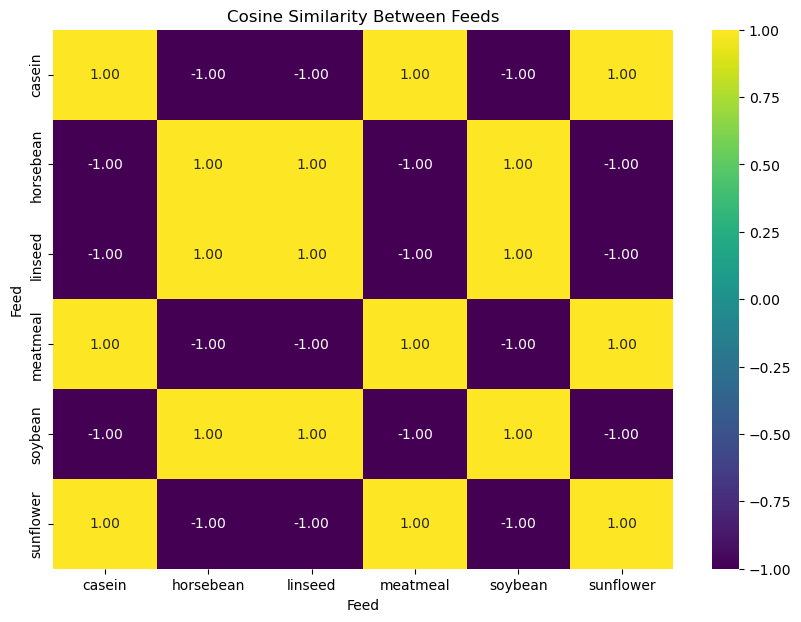

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    similarity_df,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Cosine Similarity Between Feeds")
plt.xlabel("Feed")
plt.ylabel("Feed")

plt.show()

## Creating a Recommendation function

The following function takes a feed type as input and returns the most similar
feed types based on cosine similarity.

In [35]:
def recommend_feeds(feed_name, n=3):
    
    if feed_name not in similarity_df.index:
        return f"{feed_name} is not available in the dataset."
    
    similarities = similarity_df[feed_name].drop(feed_name)
    
    recommendations = (
        similarities
        .sort_values(ascending=False)
        .head(n)
    )
    
    return recommendations

In [36]:
## Testing the recommendation system
recommend_feeds("soybean")

feed
horsebean    1.0
linseed      1.0
casein      -1.0
Name: soybean, dtype: float64

In [37]:
recommend_feeds("casein")

feed
meatmeal     1.0
sunflower    1.0
horsebean   -1.0
Name: casein, dtype: float64